# Monsoon Credit - Loan Default Prediction
### Goal: Predict whether a loan will default (TARGET=1) | Metric: ROC-AUC

In [1]:
import pandas as pd
import numpy as np
import json, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
import lightgbm as lgb

pd.set_option("display.max_columns", 50)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load Data

In [2]:
BASE = r"d:/monsoon credit/senior_ds_test/data"

train_flag = pd.read_csv(f"{BASE}/train/train_flag.csv")
test_flag  = pd.read_csv(f"{BASE}/test/test_flag.csv")
sample_sub = pd.read_csv(f"{BASE}/final_submission/sample_submission.csv")

print("Train shape:", train_flag.shape)
print("Test shape:", test_flag.shape)
train_flag.head(3)

Train shape: (261383, 3)
Test shape: (46127, 2)


,uid,NAME_CONTRACT_TYPE,TARGET
0,XDA69787158,Cash loans,0
1,BSE47789733,Cash loans,0
2,NTJ92213825,Cash loans,0


In [3]:
print("TARGET distribution:")
print(train_flag["TARGET"].value_counts())
print("Default rate:", round(train_flag["TARGET"].mean()*100, 2), "%")

TARGET distribution:
TARGET
0    240326
1     21057
Name: count, dtype: int64
Default rate: 8.06 %


In [4]:
print("Loading accounts_data_train...")
with open(f"{BASE}/train/accounts_data_train.json") as f:
    acc_train_raw = json.load(f)

print("Loading enquiry_data_train...")
with open(f"{BASE}/train/enquiry_data_train.json") as f:
    enq_train_raw = json.load(f)

print("Loading accounts_data_test...")
with open(f"{BASE}/test/accounts_data_test.json") as f:
    acc_test_raw = json.load(f)

print("Loading enquiry_data_test...")
with open(f"{BASE}/test/enquiry_data_test.json") as f:
    enq_test_raw = json.load(f)

print("All data loaded.")

Loading accounts_data_train...


Loading enquiry_data_train...


Loading accounts_data_test...


Loading enquiry_data_test...


All data loaded.


## 2. Exploratory Data Analysis

In [5]:
# Flatten to DataFrames for EDA
acc_flat = [rec for group in acc_train_raw for rec in group]
acc_df = pd.DataFrame(acc_flat)
print("Accounts flat shape:", acc_df.shape)
acc_df.head(3)

Accounts flat shape: (1245310, 7)


,credit_type,loan_amount,amount_overdue,open_date,closed_date,payment_hist_string,uid
0,Consumer credit,272745.000,0.0,2018-09-22,2020-02-22,0000000000000000000000100000000000000000000000...,AAA09044550
1,Consumer credit,4500.000,0.0,2018-03-08,2019-07-25,000000000000000014044000000000000000000000000000,AAA09044550
2,Credit card,80996.445,0.0,2020-06-29,NaN,000000000000000000,AAA10545297


In [6]:
enq_flat = [rec for group in enq_train_raw for rec in group]
enq_df = pd.DataFrame(enq_flat)
print("Enquiry flat shape:", enq_df.shape)
enq_df.head(3)

Enquiry flat shape: (1909926, 4)


,enquiry_type,enquiry_amt,enquiry_date,uid
0,Interbank credit,168839,2020-11-08,AAA08065248
1,Mobile operator loan,268392,2020-09-20,AAA08065248
2,Mobile operator loan,36082,2020-06-19,AAA08065248


In [7]:
print("Accounts null counts:")
print(acc_df.isnull().sum())
print("\nEnquiry null counts:")
print(enq_df.isnull().sum())

Accounts null counts:


credit_type                 0
loan_amount                 3
amount_overdue              0
open_date                   0
closed_date            463035
payment_hist_string         0
uid                         0
dtype: int64

Enquiry null counts:


enquiry_type    0
enquiry_amt     0
enquiry_date    0
uid             0
dtype: int64


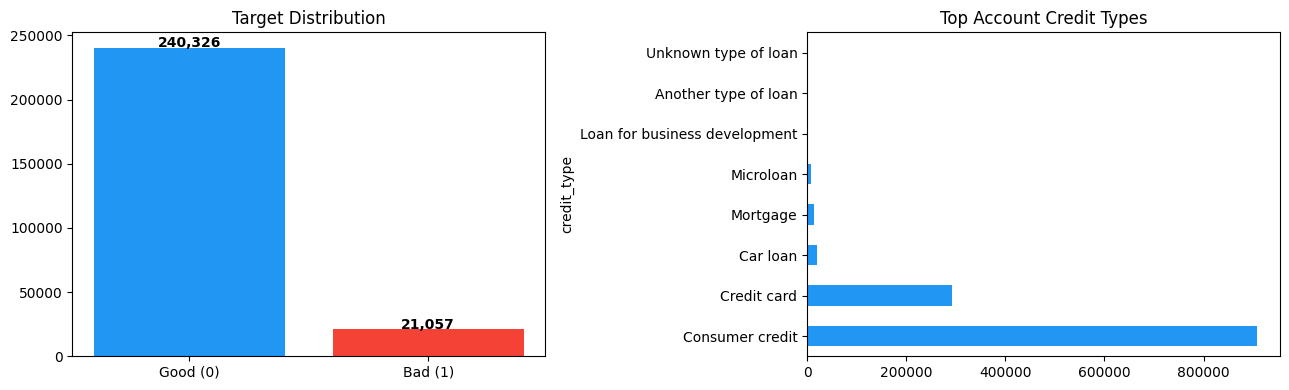

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Target distribution
counts = train_flag["TARGET"].value_counts()
axes[0].bar(["Good (0)", "Bad (1)"], counts.values, color=["#2196F3","#F44336"])
axes[0].set_title("Target Distribution")
for i,v in enumerate(counts.values):
    axes[0].text(i, v+500, f"{v:,}", ha="center", fontweight="bold")

# Top credit types
acc_df["credit_type"].value_counts().head(8).plot(kind="barh", ax=axes[1], color="#2196F3")
axes[1].set_title("Top Account Credit Types")
plt.tight_layout()
plt.show()

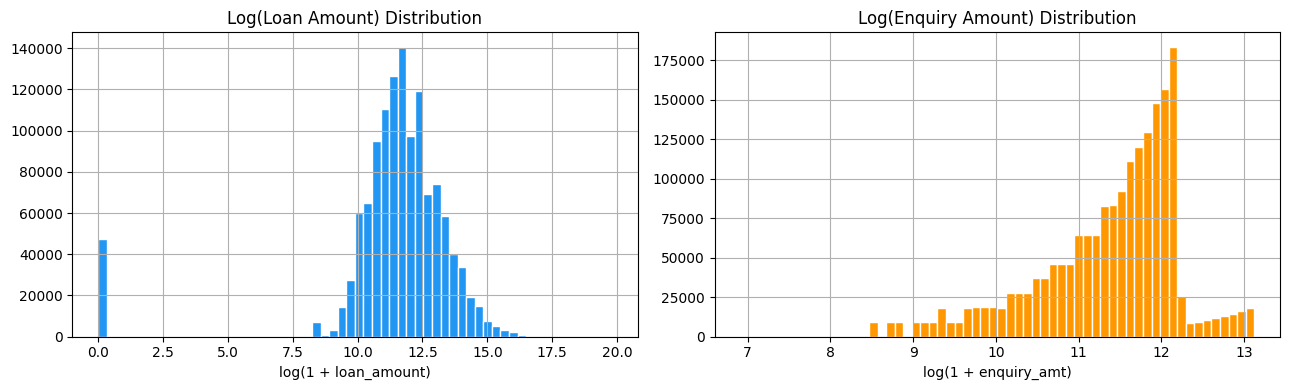

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

np.log1p(acc_df["loan_amount"].dropna()).hist(bins=60, ax=axes[0], color="#2196F3", edgecolor="white")
axes[0].set_title("Log(Loan Amount) Distribution")
axes[0].set_xlabel("log(1 + loan_amount)")

np.log1p(enq_df["enquiry_amt"].dropna()).hist(bins=60, ax=axes[1], color="#FF9800", edgecolor="white")
axes[1].set_title("Log(Enquiry Amount) Distribution")
axes[1].set_xlabel("log(1 + enquiry_amt)")

plt.tight_layout()
plt.show()

In [10]:
# Merge acc with target to see overdue vs default
acc_with_target = acc_df.merge(train_flag[["uid","TARGET"]], on="uid", how="left")
print("Avg overdue by target:")
print(acc_with_target.groupby("TARGET")["amount_overdue"].mean())

Avg overdue by target:
TARGET
0     30.218418
1    180.955848
Name: amount_overdue, dtype: float64


## 3. Feature Engineering

In [11]:
def parse_payment_hist(s):
    """Parse payment_hist_string: 3 chars per month = days past due."""
    if not isinstance(s, str) or len(s) == 0:
        return {"max_dpd": 0, "avg_dpd": 0.0, "bad_months": 0, "total_months": 0}
    vals = []
    # Try 3-digit grouping
    for i in range(0, len(s) - 2, 3):
        try:
            vals.append(int(s[i:i+3]))
        except:
            pass
    if not vals:
        vals = [int(c) for c in s if c.isdigit()]
    if not vals:
        return {"max_dpd": 0, "avg_dpd": 0.0, "bad_months": 0, "total_months": 0}
    return {
        "max_dpd": max(vals),
        "avg_dpd": float(np.mean(vals)),
        "bad_months": sum(1 for v in vals if v > 0),
        "total_months": len(vals)
    }

# Test
print(parse_payment_hist("000026000"))  # -> max=26
print(parse_payment_hist("000000000000000000000010000"))

{'max_dpd': 26, 'avg_dpd': 8.666666666666666, 'bad_months': 1, 'total_months': 3}
{'max_dpd': 10, 'avg_dpd': 1.1111111111111112, 'bad_months': 1, 'total_months': 9}


In [12]:
REF_DATE = datetime(2021, 1, 1)

def build_account_features(raw_list):
    """Aggregate per-uid features from list-of-lists account data."""
    rows = []
    for group in raw_list:
        if not group:
            continue
        uid = group[0]["uid"]
        n = len(group)

        amounts = [r["loan_amount"] for r in group
                   if r.get("loan_amount") is not None
                   and not (isinstance(r.get("loan_amount"), float) and np.isnan(r["loan_amount"]))]
        overdues = [r["amount_overdue"] for r in group
                    if r.get("amount_overdue") is not None
                    and not (isinstance(r.get("amount_overdue"), float) and np.isnan(r["amount_overdue"]))]

        total_loan    = sum(amounts)
        total_overdue = sum(overdues)
        max_loan      = max(amounts) if amounts else 0

        n_open = sum(1 for r in group if
                     r.get("closed_date") is None or
                     (isinstance(r.get("closed_date"), float) and np.isnan(r["closed_date"])))
        n_closed = n - n_open

        dpd_list = [parse_payment_hist(r.get("payment_hist_string", "")) for r in group]
        all_max_dpd    = max(d["max_dpd"] for d in dpd_list)
        all_avg_dpd    = float(np.mean([d["avg_dpd"] for d in dpd_list]))
        total_bad_mo   = sum(d["bad_months"] for d in dpd_list)
        total_hist_mo  = sum(d["total_months"] for d in dpd_list)

        ctypes = [r.get("credit_type", "").lower() for r in group]
        n_cc       = sum(1 for c in ctypes if "credit card" in c)
        n_consumer = sum(1 for c in ctypes if "consumer" in c)
        n_mortgage = sum(1 for c in ctypes if "mortgage" in c or "real estate" in c)

        ages = []
        for r in group:
            try:
                ages.append((REF_DATE - datetime.strptime(r["open_date"], "%Y-%m-%d")).days / 30)
            except:
                pass

        rows.append({
            "uid": uid,
            "acc_n_loans": n,
            "acc_total_loan_amount": total_loan,
            "acc_max_loan_amount": max_loan,
            "acc_total_overdue": total_overdue,
            "acc_n_open": n_open,
            "acc_n_closed": n_closed,
            "acc_open_ratio": n_open / n if n else 0,
            "acc_max_dpd": all_max_dpd,
            "acc_avg_dpd": all_avg_dpd,
            "acc_total_bad_months": total_bad_mo,
            "acc_total_hist_months": total_hist_mo,
            "acc_bad_month_rate": total_bad_mo / total_hist_mo if total_hist_mo > 0 else 0,
            "acc_n_credit_card": n_cc,
            "acc_n_consumer": n_consumer,
            "acc_n_mortgage": n_mortgage,
            "acc_avg_loan_age_months": float(np.mean(ages)) if ages else 0,
            "acc_oldest_loan_months": max(ages) if ages else 0,
            "acc_has_overdue": int(total_overdue > 0),
            "acc_overdue_ratio": total_overdue / (total_loan + 1),
            "acc_ever_bad": int(all_max_dpd > 0),
            "acc_severely_bad": int(all_max_dpd >= 60),
        })
    return pd.DataFrame(rows)

print("Building account features for train...")
acc_feat_train = build_account_features(acc_train_raw)
print("Building account features for test...")
acc_feat_test  = build_account_features(acc_test_raw)
print("Train account features shape:", acc_feat_train.shape)
acc_feat_train.head(3)

Building account features for train...


Building account features for test...


Train account features shape: (223918, 22)


,uid,acc_n_loans,acc_total_loan_amount,acc_max_loan_amount,acc_total_overdue,acc_n_open,acc_n_closed,acc_open_ratio,acc_max_dpd,acc_avg_dpd,acc_total_bad_months,acc_total_hist_months,acc_bad_month_rate,acc_n_credit_card,acc_n_consumer,acc_n_mortgage,acc_avg_loan_age_months,acc_oldest_loan_months,acc_has_overdue,acc_overdue_ratio,acc_ever_bad,acc_severely_bad
0,AAA09044550,2,277245.000,272745.000,0.0,0,2,0.0,44,2.106618,3,33,0.090909,0,2,0,31.033333,34.333333,0,0.0,1,0
1,AAA10545297,1,80996.445,80996.445,0.0,1,0,1.0,0,0.000000,0,6,0.000000,1,0,0,6.200000,6.200000,0,0.0,0,0
2,AAA14112888,1,43771.500,43771.500,0.0,0,1,0.0,0,0.000000,0,3,0.000000,0,1,0,6.866667,6.866667,0,0.0,0,0


In [13]:
def build_enquiry_features(raw_list):
    """Aggregate per-uid features from list-of-lists enquiry data."""
    rows = []
    for group in raw_list:
        if not group:
            continue
        uid = group[0]["uid"]
        n = len(group)

        amts = [r["enquiry_amt"] for r in group if r.get("enquiry_amt") is not None]
        total_amt = sum(amts)
        avg_amt   = total_amt / n if n else 0
        max_amt   = max(amts) if amts else 0

        dates = []
        for r in group:
            try:
                dates.append(datetime.strptime(r["enquiry_date"], "%Y-%m-%d"))
            except:
                pass

        last_enq_days  = (REF_DATE - max(dates)).days if dates else 9999
        first_enq_days = (REF_DATE - min(dates)).days if dates else 9999
        enq_span_days  = (max(dates) - min(dates)).days if len(dates) > 1 else 0

        cut6m  = datetime(2020, 7, 1)
        cut12m = datetime(2020, 1, 1)
        recent_6m  = sum(1 for d in dates if d >= cut6m)
        recent_12m = sum(1 for d in dates if d >= cut12m)

        types = [r.get("enquiry_type", "").lower() for r in group]
        n_cash      = sum(1 for t in types if "cash" in t)
        n_interbank = sum(1 for t in types if "interbank" in t)
        n_car       = sum(1 for t in types if "car" in t)

        rows.append({
            "uid": uid,
            "enq_n_enquiries": n,
            "enq_total_amt": total_amt,
            "enq_avg_amt": avg_amt,
            "enq_max_amt": max_amt,
            "enq_last_enq_days": last_enq_days,
            "enq_first_enq_days": first_enq_days,
            "enq_span_days": enq_span_days,
            "enq_recent_6m": recent_6m,
            "enq_recent_12m": recent_12m,
            "enq_n_cash": n_cash,
            "enq_n_interbank": n_interbank,
            "enq_n_car": n_car,
            "enq_amt_per_enquiry": total_amt / n if n else 0,
        })
    return pd.DataFrame(rows)

print("Building enquiry features for train...")
enq_feat_train = build_enquiry_features(enq_train_raw)
print("Building enquiry features for test...")
enq_feat_test  = build_enquiry_features(enq_test_raw)
print("Train enquiry features shape:", enq_feat_train.shape)
enq_feat_train.head(3)

Building enquiry features for train...


Building enquiry features for test...


Train enquiry features shape: (261383, 14)


,uid,enq_n_enquiries,enq_total_amt,enq_avg_amt,enq_max_amt,enq_last_enq_days,enq_first_enq_days,enq_span_days,enq_recent_6m,enq_recent_12m,enq_n_cash,enq_n_interbank,enq_n_car,enq_amt_per_enquiry
0,AAA08065248,11,2064658,187696.181818,364751,2,672,670,4,7,1,3,0,187696.181818
1,AAA09044550,26,2659000,102269.230769,197000,3,1172,1169,11,19,8,2,4,102269.230769
2,AAA10545297,14,1317000,94071.428571,192000,64,910,846,4,9,4,1,2,94071.428571


In [14]:
# Merge all
train = train_flag.merge(acc_feat_train, on="uid", how="left")
train = train.merge(enq_feat_train, on="uid", how="left")

test  = test_flag.merge(acc_feat_test,  on="uid", how="left")
test  = test.merge(enq_feat_test,  on="uid", how="left")

# Contract type flag
train["is_revolving"] = (train["NAME_CONTRACT_TYPE"] == "Revolving loans").astype(int)
test["is_revolving"]  = (test["NAME_CONTRACT_TYPE"]  == "Revolving loans").astype(int)

FEAT_COLS = [c for c in train.columns if c not in ["uid", "NAME_CONTRACT_TYPE", "TARGET"]]

# Fill missing (users with no account/enquiry history)
train[FEAT_COLS] = train[FEAT_COLS].fillna(0)
test[FEAT_COLS]  = test[FEAT_COLS].fillna(0)

X      = train[FEAT_COLS].values
y      = train["TARGET"].values
X_test = test[FEAT_COLS].values

print("X shape:", X.shape, "| y shape:", y.shape)
print("X_test shape:", X_test.shape)
print("Features:", FEAT_COLS)

X shape: (261383, 35) | y shape: (261383,)
X_test shape: (46127, 35)
Features: ['acc_n_loans', 'acc_total_loan_amount', 'acc_max_loan_amount', 'acc_total_overdue', 'acc_n_open', 'acc_n_closed', 'acc_open_ratio', 'acc_max_dpd', 'acc_avg_dpd', 'acc_total_bad_months', 'acc_total_hist_months', 'acc_bad_month_rate', 'acc_n_credit_card', 'acc_n_consumer', 'acc_n_mortgage', 'acc_avg_loan_age_months', 'acc_oldest_loan_months', 'acc_has_overdue', 'acc_overdue_ratio', 'acc_ever_bad', 'acc_severely_bad', 'enq_n_enquiries', 'enq_total_amt', 'enq_avg_amt', 'enq_max_amt', 'enq_last_enq_days', 'enq_first_enq_days', 'enq_span_days', 'enq_recent_6m', 'enq_recent_12m', 'enq_n_cash', 'enq_n_interbank', 'enq_n_car', 'enq_amt_per_enquiry', 'is_revolving']


In [15]:
# Feature correlation with target
corr = train[FEAT_COLS + ["TARGET"]].corr()["TARGET"].drop("TARGET").sort_values(key=abs, ascending=False)
print("Top 15 features by correlation with TARGET:")
print(corr.head(15).round(4))

Top 15 features by correlation with TARGET:
acc_avg_loan_age_months   -0.0836
acc_oldest_loan_months    -0.0726
enq_first_enq_days         0.0717
acc_open_ratio             0.0482
enq_span_days              0.0477
acc_n_open                 0.0447
acc_n_closed              -0.0357
enq_last_enq_days          0.0323
enq_recent_6m             -0.0316
acc_has_overdue            0.0310
is_revolving              -0.0310
acc_total_hist_months     -0.0294
enq_recent_12m            -0.0250
acc_n_mortgage            -0.0232
enq_max_amt               -0.0229
Name: TARGET, dtype: float64


## 4. Baseline – Logistic Regression

In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced", C=0.1, random_state=42))
])

lr_scores = cross_val_score(lr_pipe, X, y, cv=skf, scoring="roc_auc", n_jobs=-1)
print("Logistic Regression 5-Fold CV ROC-AUC scores:", lr_scores.round(4))
print(f"Mean: {lr_scores.mean():.4f} | Std: {lr_scores.std():.4f}")

Logistic Regression 5-Fold CV ROC-AUC scores: [0.6706 0.6707 0.6713 0.6663 0.6671]
Mean: 0.6692 | Std: 0.0021


## 5. Advanced Model – LightGBM with Early Stopping

In [17]:
lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.05,
    "num_leaves": 64,
    "max_depth": -1,
    "min_child_samples": 50,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "scale_pos_weight": (y == 0).sum() / (y == 1).sum(),
    "random_state": 42,
    "verbose": -1,
}

oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores = []
best_models = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, feature_name=FEAT_COLS)
    dval   = lgb.Dataset(X_val, label=y_val, feature_name=FEAT_COLS)

    model = lgb.train(
        lgb_params, dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=200)
        ]
    )

    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred
    test_preds += model.predict(X_test) / skf.n_splits
    score = roc_auc_score(y_val, val_pred)
    fold_scores.append(score)
    best_models.append(model)
    print(f"  Fold {fold+1} | AUC: {score:.4f} | Best iter: {model.best_iteration}")

oof_auc = roc_auc_score(y, oof_preds)
print(f"\nLightGBM OOF AUC : {oof_auc:.4f}")
print(f"Mean fold AUC    : {np.mean(fold_scores):.4f} +/- {np.std(fold_scores):.4f}")

[200]	valid_0's auc: 0.672441


  Fold 1 | AUC: 0.6739 | Best iter: 109


  Fold 2 | AUC: 0.6695 | Best iter: 93


[200]	valid_0's auc: 0.672651


  Fold 3 | AUC: 0.6733 | Best iter: 161


[200]	valid_0's auc: 0.671926


  Fold 4 | AUC: 0.6720 | Best iter: 193


[200]	valid_0's auc: 0.664619


  Fold 5 | AUC: 0.6659 | Best iter: 106

LightGBM OOF AUC : 0.6709
Mean fold AUC    : 0.6709 +/- 0.0029


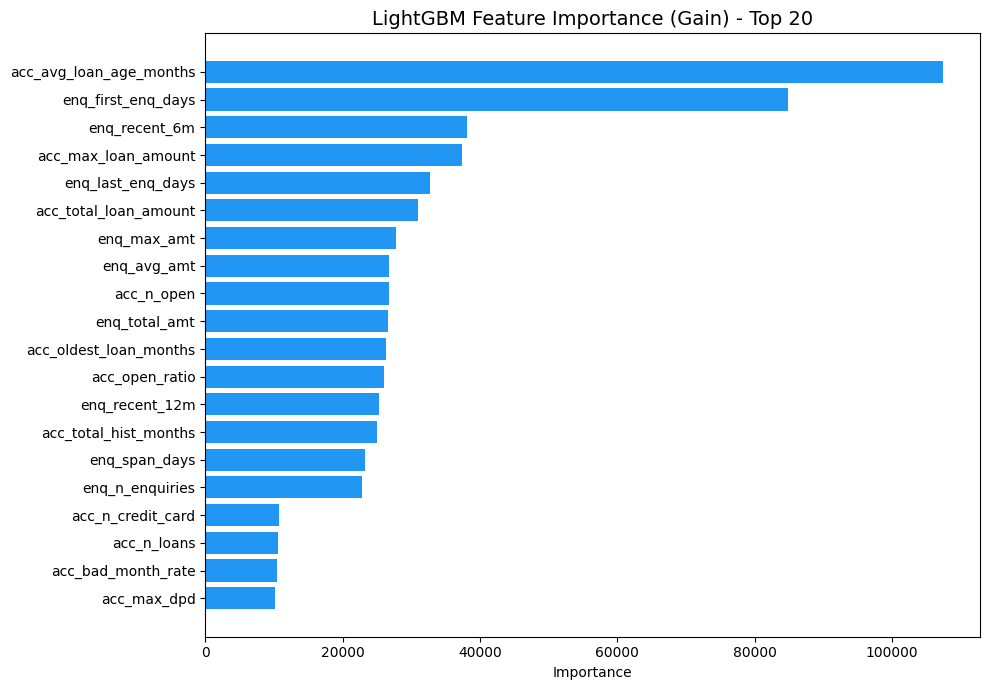

In [18]:
# Feature importance
importances = np.mean([m.feature_importance("gain") for m in best_models], axis=0)
imp_df = pd.DataFrame({"feature": FEAT_COLS, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=True).tail(20)

plt.figure(figsize=(10, 7))
plt.barh(imp_df["feature"], imp_df["importance"], color="#2196F3")
plt.title("LightGBM Feature Importance (Gain) - Top 20", fontsize=14)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

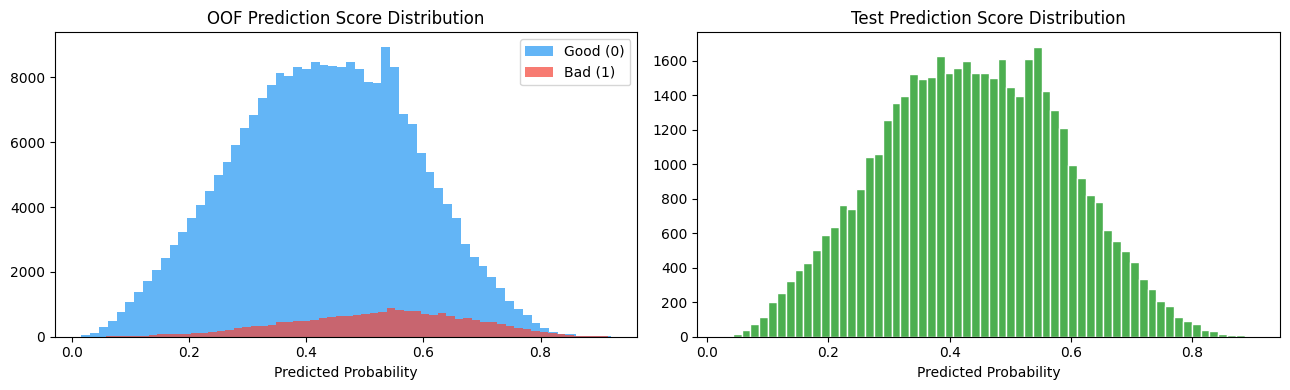

In [19]:
# OOF prediction distribution by class
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(oof_preds[y==0], bins=60, alpha=0.7, color="#2196F3", label="Good (0)")
axes[0].hist(oof_preds[y==1], bins=60, alpha=0.7, color="#F44336", label="Bad (1)")
axes[0].set_title("OOF Prediction Score Distribution")
axes[0].set_xlabel("Predicted Probability")
axes[0].legend()

axes[1].hist(test_preds, bins=60, color="#4CAF50", edgecolor="white")
axes[1].set_title("Test Prediction Score Distribution")
axes[1].set_xlabel("Predicted Probability")

plt.tight_layout()
plt.show()

## 6. Model Comparison

In [20]:
print("=" * 50)
print(f"  Logistic Regression CV AUC : {lr_scores.mean():.4f}")
print(f"  LightGBM OOF AUC           : {oof_auc:.4f}")
print("=" * 50)
print("LightGBM improvement over LR:", round((oof_auc - lr_scores.mean())*100, 2), "percentage points")

  Logistic Regression CV AUC : 0.6692
  LightGBM OOF AUC           : 0.6709
LightGBM improvement over LR: 0.17 percentage points


## 7. Final Submission

In [21]:
submission = pd.DataFrame({"uid": test["uid"], "pred": test_preds})
out_path = r"d:/monsoon credit/senior_ds_test/data/final_submission/final_submission_tejasv_gupta.csv"
submission.to_csv(out_path, index=False)

print("Submission saved to:", out_path)
print("Shape:", submission.shape)
print("Pred stats:")
print(submission["pred"].describe().round(4))
submission.head()

Submission saved to: d:/monsoon credit/senior_ds_test/data/final_submission/final_submission_tejasv_gupta.csv
Shape: (46127, 2)
Pred stats:
count    46127.0000
mean         0.4371
std          0.1502
min          0.0273
25%          0.3283
50%          0.4376
75%          0.5461
max          0.9018
Name: pred, dtype: float64


,uid,pred
0,CMO22835242,0.325127
1,MRJ34316727,0.655460
2,UAV00534378,0.542237
3,IPQ08190402,0.487745
4,NQN84331006,0.476307
